<a href="https://colab.research.google.com/github/miaalvaradoc/IA-TEAM-ASSIGNMENTS/blob/main/ASSIGNMENTS/Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 4.- Supervised Learning Model: Decision Tree**

*Class Hour: 2:30 - 5:00 p.m. (LMMJV)*


*   Mia Alvarado Cruz - 2114905
*   María Fernanda Soriano Lara - 2177962
*   Ana Lucía Vasquez Andrade - 2095379
*   Alani Monserrath Molina Rosas - 2114717

# **Part 1: Data Loading and Exploration**


First, we import the libraries we're going to need in this assignment.

In [ ]:
#Libraries
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree


Then we load the breast cancer dataset from a specified URL and then displays the first 10 rows to provide a quick overview of the data.

In [ ]:
# Download the Breast Cancer Wisconsin (Diagnostic) dataset
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

# Load the dataset into a Pandas DataFrame
df = pd.read_csv(os.path.join(path, "data.csv"))

# Display the first 10 rows of the dataset
df.head(10)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN


Check for missing values

In [ ]:
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

# **Part 2: Data Preprocessing / Normilize Data**

Now we define the features and targets of the model and normalize the data

In [ ]:
# Define features and target label
X1 = df.drop(columns=["diagnosis"]).values
y = df["diagnosis"].values

# Apply Min-Max normalization to the input features
norm = np.array(X1)
Min = np.min(norm, axis=0)
Max = np.max(norm, axis=0)
X = (norm - Min) / (Max - Min)

# Display the number of samples for each diagnosis
print(df["diagnosis"].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


In [ ]:
# Store the feature and class names for visualization
feature_names = df.drop(columns=["diagnosis"]).columns
target_names = ["Benign", "Malignant"]

Here we are going to define the % of de trainig values as 80% training and 20% testing

In [ ]:
# Split the dataset into training and testing data
# 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=42)

# Display the number of training and testing samples
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 455
Testing samples: 114


# **Part 3: Model selection, training, and evaluation**

In [ ]:
#Model selection and training

clf = DecisionTreeClassifier(max_depth=3,random_state=42)

# Train the model using the training dataset
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

Now we compare the train and test accuracy

In [ ]:
# Training accuracy

train_accuracy = clf.score(X_train, y_train)
print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.978021978021978


In [ ]:
# Generate predictions using the testing dataset

y_pred = clf.predict(X_test)

# Calculate the testing accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9385964912280702


Print the classification report

In [ ]:
# Classification report
print("Classification Report:\n")
print(classification_report(y_test,y_pred,target_names=["Benign", "Malignant"]))

Classification Report:

              precision    recall  f1-score   support

      Benign       0.94      0.96      0.95        71
   Malignant       0.93      0.91      0.92        43

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



# **Part 4: Show the decision tree**

Lastly we print the visualization of the decision tree


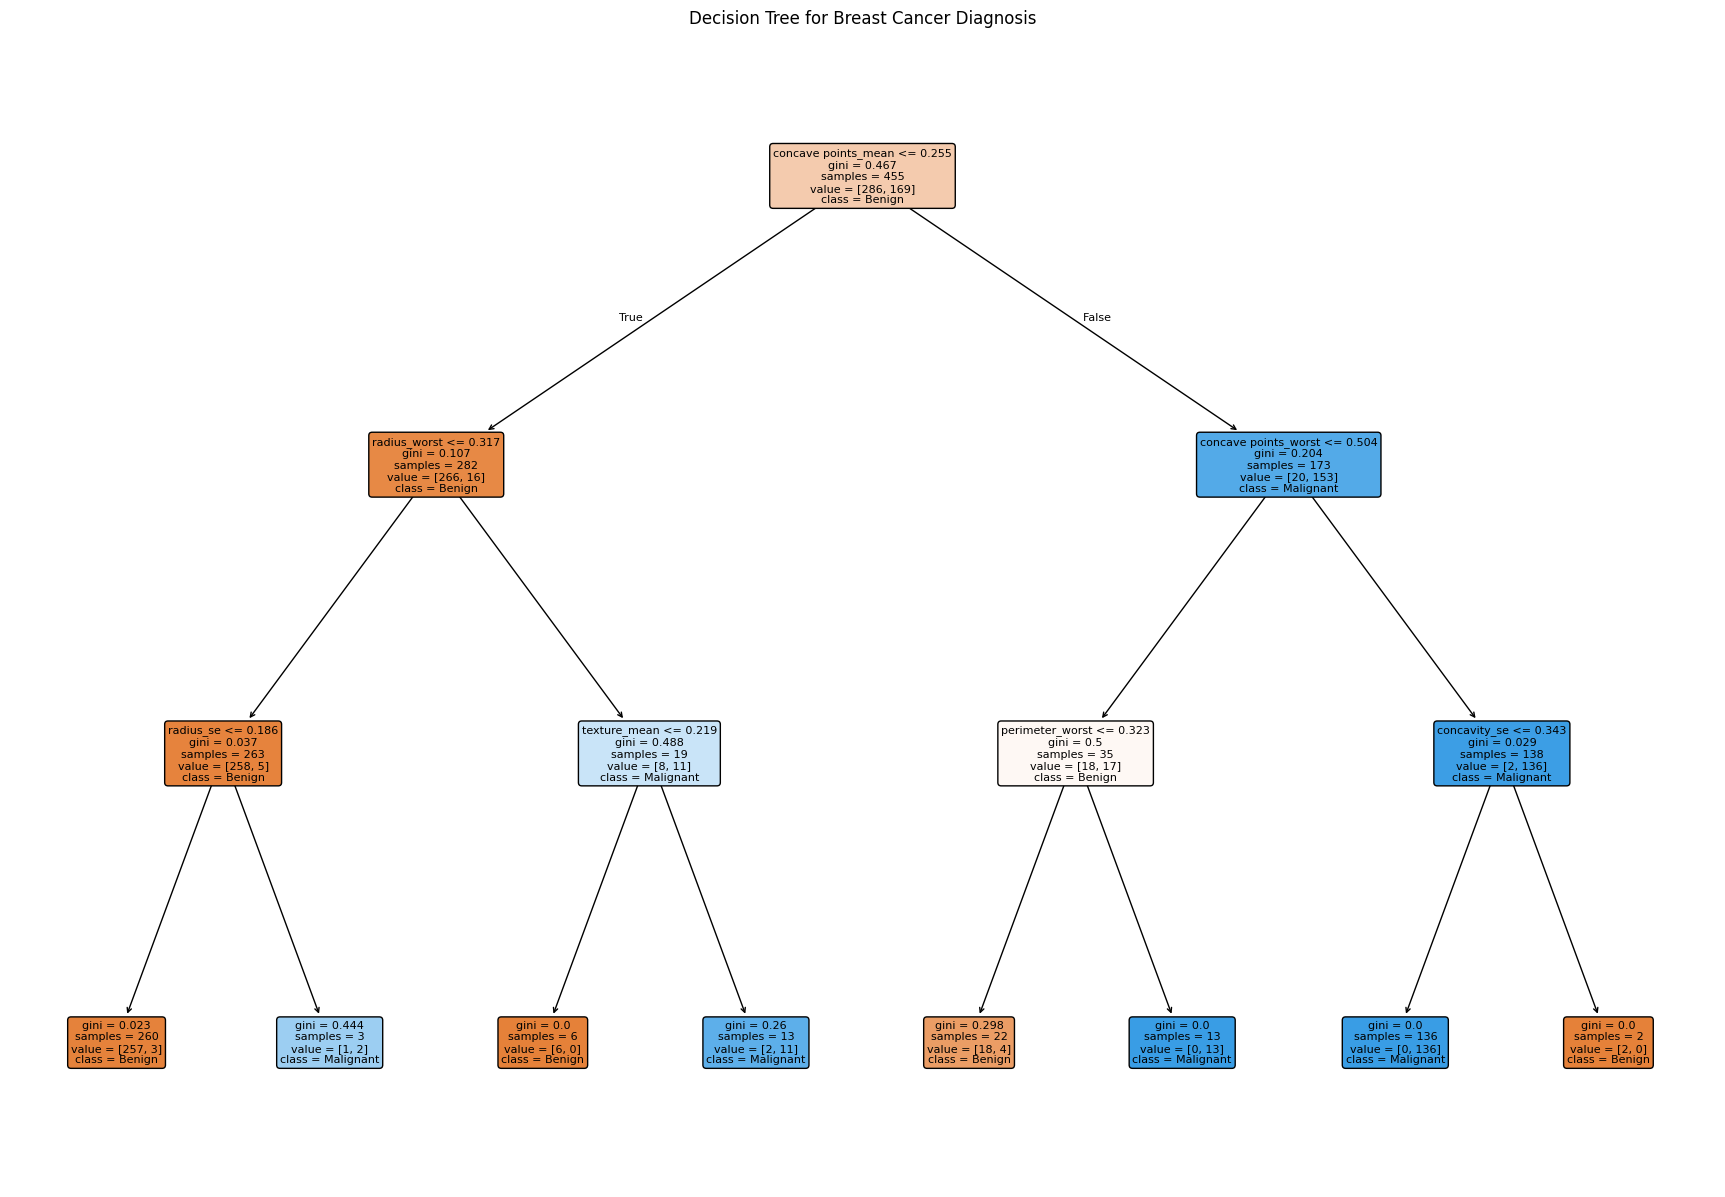

In [ ]:
# Plot the trained decision tree
plt.figure(figsize=(22,15))
tree.plot_tree(clf,filled=True,feature_names=feature_names,class_names=["Benign","Malignant"],rounded=True,fontsize=8)

# Add a title to the figure
plt.title("Decision Tree for Breast Cancer Diagnosis")

# Save the figure with 300 DPI resolution
plt.savefig("Decision_Tree.png", dpi=300)

# Display the decision tree
plt.show()